In [1]:
# Mount Google Drive to access project files
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/Project"

Mounted at /content/drive


In [2]:
!pip install -q pymatgen torch-geometric torch-cluster scikit-learn matplotlib shap xgboost pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import global_mean_pool, Set2Set, MessagePassing
from torch_geometric.utils import scatter
from torch_cluster import radius_graph
from pymatgen.core import Structure, Element

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from pysr import PySRRegressor

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | 
           | [compat]
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
[juliapkg] Installing packages:
           | impo

In [4]:
# Load dataset
df = pd.read_csv(os.path.join(PROJECT_PATH, "Final Dataset.csv"))
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7000, 17)


,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-331,ScAl,Pm3m,221,2.0,0.0000,3.370349,3.370349,3.370349,90.000000,90.000000,90.000000,17.000000,1.485,TI,1,cif_files/mp-331.cif
1,mp-698479,RbTeHOF4,Cc,9,32.0,4.8825,8.430517,8.430517,14.075609,85.886490,85.886490,34.382176,16.750000,3.060,Trivial,0,cif_files/mp-698479.cif
2,mp-549237,Sr2Fe2S2OF2,I4/mmm,139,18.0,1.4677,4.095118,4.096245,18.221803,90.002343,90.003680,89.993481,20.666667,2.458,Trivial,0,cif_files/mp-549237.cif
3,mp-13089,Cu2SnTe3,Imm2,44,6.0,0.0000,4.409910,6.113668,7.554224,113.869340,106.970766,90.000000,44.000000,2.010,Trivial,0,cif_files/mp-13089.cif
4,mp-10732,ThTaN3,Pm-3m,221,5.0,0.0766,4.064437,4.064437,4.064437,90.000000,90.000000,90.000000,36.800000,2.384,Topological,1,cif_files/mp-10732.cif


In [5]:
# Keep only relevant columns
df = df.drop(columns=['mp_material_id', 'mp_formula', 'Topological Label'])
print("Columns after dropping:", df.columns.tolist())

Columns after dropping: ['spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'label', 'cif']


In [6]:
# Split into train (70%), temp (30%)
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

# Split temp into val (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("Train label distribution:\n", train_df['label'].value_counts())
print("Val label distribution:\n", val_df['label'].value_counts())
print("Test label distribution:\n", test_df['label'].value_counts())

Train: 4900, Val: 1050, Test: 1050
Train label distribution:
 label
0    2475
1    2425
Name: count, dtype: int64
Val label distribution:
 label
0    530
1    520
Name: count, dtype: int64
Test label distribution:
 label
0    531
1    519
Name: count, dtype: int64


In [7]:
global_cols = [
    'spacegroup_number', 'number of atoms', 'Band Gap',
    'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity'
]

scaler = StandardScaler()

train_df[global_cols] = scaler.fit_transform(train_df[global_cols])
val_df[global_cols]   = scaler.transform(val_df[global_cols])
test_df[global_cols]  = scaler.transform(test_df[global_cols])

print("Global features scaled.")

Global features scaled.


In [8]:
def get_node_features(structure):
    """Return node feature matrix for a given pymatgen Structure."""
    node_features = []
    for site in structure:
        el = site.specie
        # Attempt to get properties; fallback to 0 if missing
        atomic_number = el.Z if el.Z is not None else 0
        electronegativity = el.X if el.X is not None else 0.0
        atomic_radius = el.atomic_radius if el.atomic_radius is not None else 0.0
        valence = el.nvalence() if hasattr(el, 'nvalence') else 0
        row = el.row if el.row is not None else 0
        group = el.group if el.group is not None else 0
        ioniz_energy = el.ionization_energy if el.ionization_energy is not None else 0.0
        electron_aff = el.electron_affinity if el.electron_affinity is not None else 0.0
        node_features.append([
            atomic_number, electronegativity, atomic_radius,
            valence, row, group, ioniz_energy, electron_aff
        ])
    return torch.tensor(node_features, dtype=torch.float)

In [17]:
CUTOFF = 6.0          # Angstrom
N_RBF = 10            # number of radial basis functions

def build_graph(row):
    """Convert a DataFrame row to a PyG Data object."""
    cif_path = os.path.join(PROJECT_PATH, row['cif'])
    structure = Structure.from_file(cif_path)

    # Node features
    x = get_node_features(structure)

    # Positions
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # Edges
    edge_index = radius_graph(pos, r=CUTOFF, loop=False)
    src, dst = edge_index
    distances = torch.norm(pos[src] - pos[dst], dim=1, keepdim=True)

    # RBF expansion
    centers = torch.linspace(0, CUTOFF, N_RBF)
    edge_attr = torch.exp(-((distances - centers)**2))

    # Global features (scaled CSV columns + derived)
    global_vals = [float(row[col]) for col in global_cols]
    global_vals.append(structure.volume)
    global_vals.append(structure.density)
    global_vals.append(len(structure.composition.elements))
    u = torch.tensor(global_vals, dtype=torch.float).unsqueeze(0)

    # Label
    y = torch.tensor([row['label']], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                u=u, y=y, pos=pos)

In [19]:
def save_graphs(df, split_name):
    print(f"Starting to save graphs for {split_name} (total {len(df)} rows)...")
    graphs = []
    for idx, row in df.iterrows():
        try:
            graph = build_graph(row)
            graphs.append(graph)
            if (idx + 1) % 100 == 0 or idx == len(df) - 1:
                print(f"  Processed {idx + 1}/{len(df)} for {split_name}")
        except Exception as e:
            print(f"Error building graph for {row['cif']}: {e}")
            continue
    torch.save(graphs, os.path.join(PROJECT_PATH, f"{split_name}.pt"))
    print(f"Saved {len(graphs)} graphs to {split_name}.pt")

save_graphs(train_df, "train1")
save_graphs(val_df, "val1")
save_graphs(test_df, "test1")

Starting to save graphs for train1 (total 4900 rows)...
  Processed 3100/4900 for train1
  Processed 6300/4900 for train1
  Processed 3500/4900 for train1
  Processed 1200/4900 for train1
  Processed 1100/4900 for train1
  Processed 1900/4900 for train1
  Processed 4700/4900 for train1
  Processed 6500/4900 for train1
  Processed 5400/4900 for train1
  Processed 6900/4900 for train1
  Processed 6200/4900 for train1
  Processed 2300/4900 for train1
  Processed 4600/4900 for train1
  Processed 4900/4900 for train1
  Processed 600/4900 for train1
  Processed 1300/4900 for train1
  Processed 2500/4900 for train1
  Processed 300/4900 for train1
  Processed 700/4900 for train1
  Processed 6800/4900 for train1
  Processed 4200/4900 for train1
  Processed 3800/4900 for train1
  Processed 2900/4900 for train1
  Processed 5900/4900 for train1
  Processed 2400/4900 for train1
  Processed 2600/4900 for train1
  Processed 900/4900 for train1
  Processed 1400/4900 for train1
  Processed 1700/4900 fo

In [20]:
train_graphs = torch.load(os.path.join(PROJECT_PATH, "train1.pt"), weights_only=False)
val_graphs   = torch.load(os.path.join(PROJECT_PATH, "val1.pt"),   weights_only=False)
test_graphs  = torch.load(os.path.join(PROJECT_PATH, "test1.pt"),  weights_only=False)

In [21]:
BATCH_SIZE = 32
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 154
Val batches:   33
Test batches:  33


In [22]:
class CGCNNConv(MessagePassing):
    def __init__(self, in_channels, edge_dim):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels*2 + edge_dim, in_channels)
        self.bn = nn.BatchNorm1d(in_channels)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        z = torch.cat([x_i, x_j, edge_attr], dim=1)
        return F.relu(self.lin(z))

    def update(self, aggr_out):
        return self.bn(aggr_out)

In [23]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_feat_dim=8, edge_feat_dim=N_RBF, hidden_dim=64, global_dim=len(global_cols)+3):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)
        self.conv1 = CGCNNConv(hidden_dim, edge_feat_dim)
        self.conv2 = CGCNNConv(hidden_dim, edge_feat_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc_global = nn.Linear(global_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim*2, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x = F.relu(self.node_emb(data.x))
        x = self.conv1(x, data.edge_index, data.edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, data.edge_index, data.edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        x_pool = global_mean_pool(x, data.batch)
        u = F.relu(self.fc_global(data.u))
        x = torch.cat([x_pool, u], dim=1)
        x = self.dropout(F.relu(self.fc(x)))
        return x

In [24]:
class AttentionCGCNNConv(MessagePassing):
    def __init__(self, in_channels, edge_dim):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels*2 + edge_dim, in_channels)
        self.att = nn.Linear(in_channels*2 + edge_dim, 1)
        self.bn = nn.BatchNorm1d(in_channels)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        z = torch.cat([x_i, x_j, edge_attr], dim=1)
        alpha = torch.sigmoid(self.att(z))
        self._alpha = alpha
        return alpha * F.relu(self.lin(z))

    def update(self, aggr_out):
        return self.bn(aggr_out)

In [25]:
class CharlesAttentionCGCNN(nn.Module):
    def __init__(self, node_feat_dim=8, edge_feat_dim=N_RBF, hidden_dim=64, global_dim=len(global_cols)+3):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)
        self.conv1 = AttentionCGCNNConv(hidden_dim, edge_feat_dim)
        self.conv2 = AttentionCGCNNConv(hidden_dim, edge_feat_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc_global = nn.Linear(global_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim*2, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data, return_attention=False):
        x = F.relu(self.node_emb(data.x))
        x = self.conv1(x, data.edge_index, data.edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, data.edge_index, data.edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        if return_attention:
            self.att_weights = self.conv2._alpha

        x_pool = global_mean_pool(x, data.batch)
        u = F.relu(self.fc_global(data.u))
        x = torch.cat([x_pool, u], dim=1)
        x = self.dropout(F.relu(self.fc(x)))
        return x

In [26]:
class MEGNetBlock(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim):
        super().__init__()
        # Edge update
        self.edge_mlp = nn.Sequential(
            nn.Linear(node_dim*2 + edge_dim + global_dim, 64),
            nn.SiLU(),
            nn.Linear(64, edge_dim)
        )
        # Node update
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + edge_dim + global_dim, 64),
            nn.SiLU(),
            nn.Linear(64, node_dim)
        )
        # Global update
        self.global_mlp = nn.Sequential(
            nn.Linear(global_dim + node_dim + edge_dim, 64),
            nn.SiLU(),
            nn.Linear(64, global_dim)
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        src, dst = edge_index

        # Edge update
        edge_input = torch.cat([x[src], x[dst], edge_attr, u[batch[src]]], dim=1)
        edge_attr = self.edge_mlp(edge_input)

        # Node update
        agg = scatter(edge_attr, dst, dim=0, dim_size=x.size(0), reduce='mean')
        node_input = torch.cat([x, agg, u[batch]], dim=1)
        x = self.node_mlp(node_input)

        # Global update
        u_input = torch.cat([
            u,
            global_mean_pool(x, batch),
            global_mean_pool(edge_attr, batch[src])
        ], dim=1)
        u = self.global_mlp(u_input)

        return x, edge_attr, u

In [27]:
class CharlesMEGNet(nn.Module):
    def __init__(self, node_feat_dim=8, edge_feat_dim=N_RBF, global_dim=len(global_cols)+3, hidden_dim=64, num_blocks=3):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_feat_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            MEGNetBlock(hidden_dim, hidden_dim, hidden_dim) for _ in range(num_blocks)
        ])

        self.pool = Set2Set(hidden_dim, processing_steps=3)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim*2 + hidden_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 2)
        )

    def forward(self, data):
        x = F.silu(self.node_emb(data.x))
        e = F.silu(self.edge_emb(data.edge_attr))
        u = F.silu(self.global_emb(data.u))

        for block in self.blocks:
            x, e, u = block(x, data.edge_index, e, u, data.batch)

        x_pool = self.pool(x, data.batch)
        out = torch.cat([x_pool, u], dim=1)
        return self.fc(out)

In [28]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, weight_decay=1e-5, patience=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=patience)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        avg_loss = total_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        preds, probs, labels = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch)
                preds.extend(out.argmax(dim=1).cpu().numpy())
                probs.extend(F.softmax(out, dim=1)[:,1].cpu().numpy())
                labels.extend(batch.y.cpu().numpy())

        acc = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds)
        auc = roc_auc_score(labels, probs)

        scheduler.step(acc)

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(acc)
        history['val_f1'].append(f1)
        history['val_auc'].append(auc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

        if acc > best_val_acc:
            best_val_acc = acc
            torch.save(model.state_dict(), os.path.join(PROJECT_PATH, f"{model.__class__.__name__}_best.pth"))

    return model, history

In [29]:
model_cgcnn = CharlesCGCNN().to(device)
model_cgcnn, hist_cgcnn = train_model(model_cgcnn, train_loader, val_loader)

Epoch   1/50 | Loss: 0.9937 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch   5/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  10/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  15/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  20/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  25/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  30/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  35/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  40/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  45/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  50/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000


In [30]:
model_attn = CharlesAttentionCGCNN().to(device)
model_attn, hist_attn = train_model(model_attn, train_loader, val_loader)

Epoch   1/50 | Loss: 0.6860 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5057
Epoch   5/50 | Loss: 0.6935 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  10/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  15/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  20/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  25/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  30/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  35/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  40/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  45/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000
Epoch  50/50 | Loss: 0.6931 | Val Acc: 0.5048 | F1: 0.0000 | AUC: 0.5000


In [31]:
model_megnet = CharlesMEGNet().to(device)
model_megnet, hist_megnet = train_model(model_megnet, train_loader, val_loader)

Epoch   1/50 | Loss: 0.5746 | Val Acc: 0.7410 | F1: 0.7318 | AUC: 0.8025
Epoch   5/50 | Loss: 0.4939 | Val Acc: 0.7610 | F1: 0.7704 | AUC: 0.8469
Epoch  10/50 | Loss: 0.4222 | Val Acc: 0.8257 | F1: 0.8269 | AUC: 0.8921
Epoch  15/50 | Loss: 0.3998 | Val Acc: 0.8171 | F1: 0.8307 | AUC: 0.8983
Epoch  20/50 | Loss: 0.3754 | Val Acc: 0.8324 | F1: 0.8373 | AUC: 0.9065
Epoch  25/50 | Loss: 0.3298 | Val Acc: 0.8467 | F1: 0.8527 | AUC: 0.9176
Epoch  30/50 | Loss: 0.3141 | Val Acc: 0.8505 | F1: 0.8592 | AUC: 0.9194
Epoch  35/50 | Loss: 0.2919 | Val Acc: 0.8581 | F1: 0.8624 | AUC: 0.9218
Epoch  40/50 | Loss: 0.2872 | Val Acc: 0.8590 | F1: 0.8642 | AUC: 0.9220
Epoch  45/50 | Loss: 0.2840 | Val Acc: 0.8619 | F1: 0.8671 | AUC: 0.9221
Epoch  50/50 | Loss: 0.2814 | Val Acc: 0.8638 | F1: 0.8692 | AUC: 0.9218


In [32]:
def evaluate_model(model, loader, name="Model"):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(F.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    auc = roc_auc_score(labels, probs)
    print(f"\n=== {name} – TEST SET ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(labels, preds, target_names=['Trivial', 'Topological']))
    return labels, preds, probs

In [33]:
_ = evaluate_model(model_cgcnn, test_loader, "CharlesCGCNN")
_ = evaluate_model(model_attn,  test_loader, "CharlesAttentionCGCNN")
_ = evaluate_model(model_megnet, test_loader, "CharlesMEGNet")


=== CharlesCGCNN – TEST SET ===
Accuracy : 0.5057
F1-score : 0.0000
ROC-AUC  : 0.5000
              precision    recall  f1-score   support

     Trivial       0.51      1.00      0.67       531
 Topological       0.00      0.00      0.00       519

    accuracy                           0.51      1050
   macro avg       0.25      0.50      0.34      1050
weighted avg       0.26      0.51      0.34      1050


=== CharlesAttentionCGCNN – TEST SET ===
Accuracy : 0.5057
F1-score : 0.0000
ROC-AUC  : 0.5000
              precision    recall  f1-score   support

     Trivial       0.51      1.00      0.67       531
 Topological       0.00      0.00      0.00       519

    accuracy                           0.51      1050
   macro avg       0.25      0.50      0.34      1050
weighted avg       0.26      0.51      0.34      1050


=== CharlesMEGNet – TEST SET ===
Accuracy : 0.8248
F1-score : 0.8315
ROC-AUC  : 0.8900
              precision    recall  f1-score   support

     Trivial       0

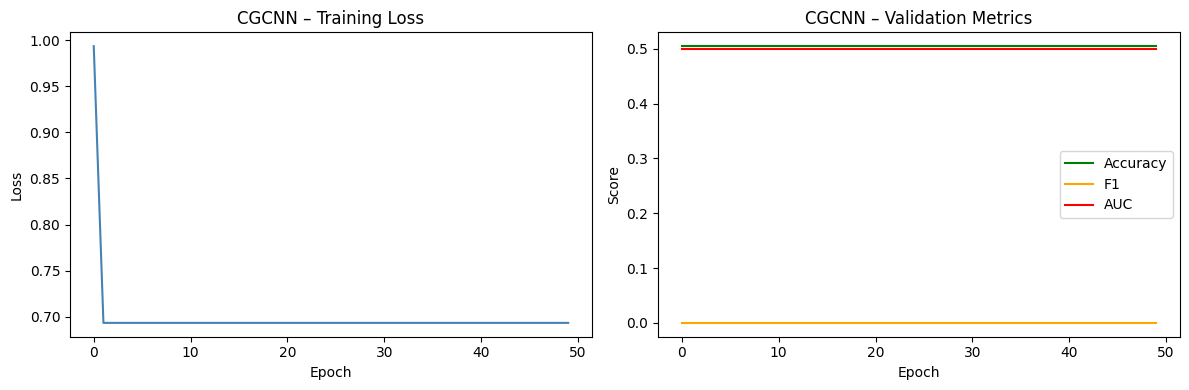

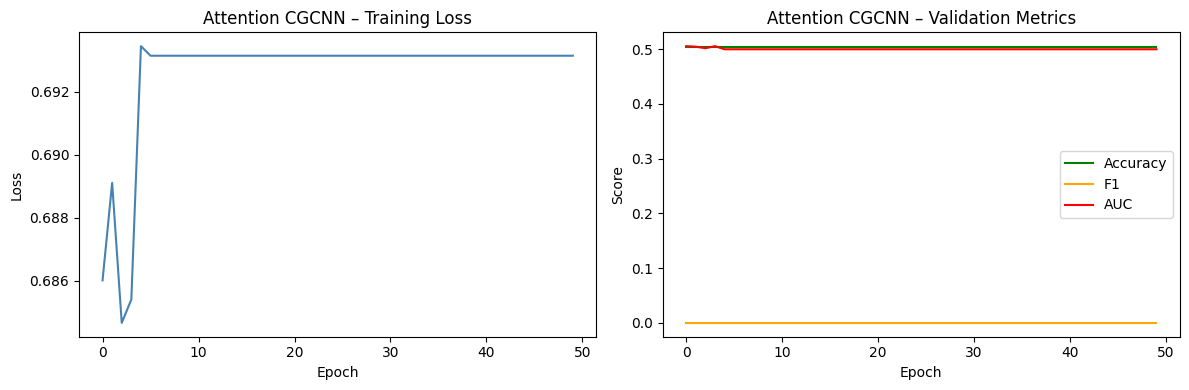

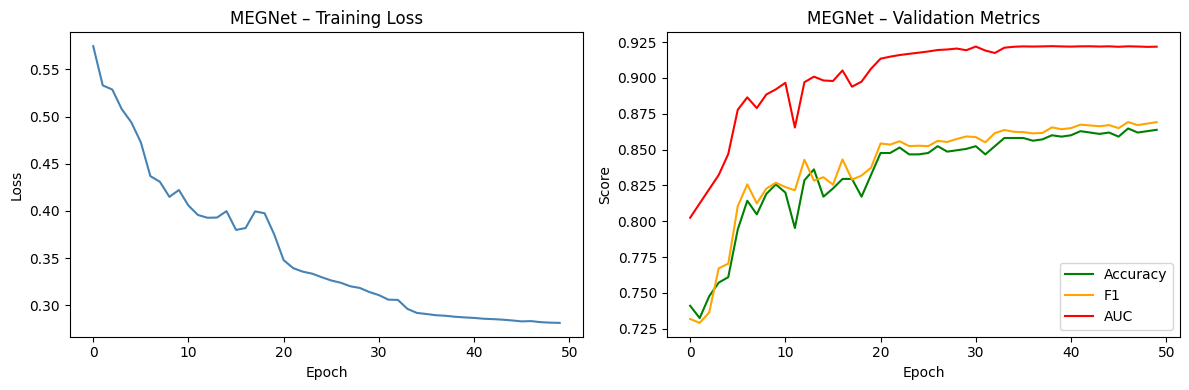

In [34]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} – Training Loss')
    axes[1].plot(history['val_acc'], label='Accuracy', color='green')
    axes[1].plot(history['val_f1'], label='F1', color='orange')
    axes[1].plot(history['val_auc'], label='AUC', color='red')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].set_title(f'{title} – Validation Metrics')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_cgcnn, "CGCNN")
plot_history(hist_attn, "Attention CGCNN")
plot_history(hist_megnet, "MEGNet")

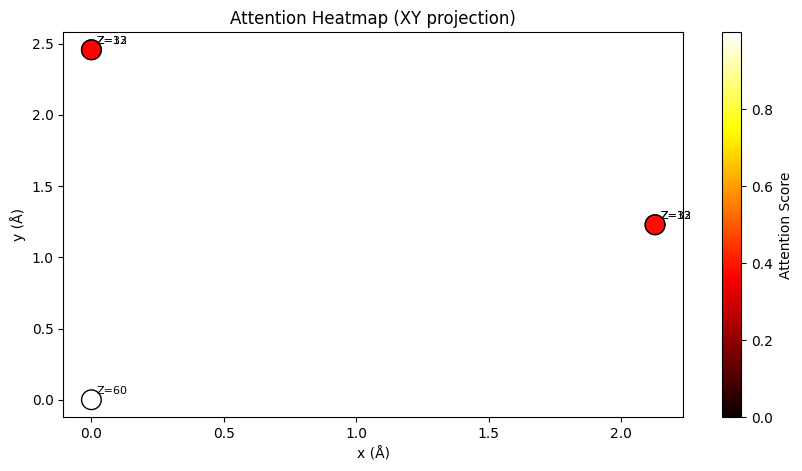

In [35]:
# Get a single topological insulator test sample
model_attn.eval()
ti_sample = None
for batch in test_loader:
    batch = batch.to(device)
    for i in range(batch.num_graphs):
        if batch.y[i].item() == 1:
            # Extract single graph
            mask = (batch.batch == i)
            x_i = batch.x[mask]
            pos_i = batch.pos[mask]
            edge_mask = mask[batch.edge_index[0]] | mask[batch.edge_index[1]]
            ei_i = batch.edge_index[:, edge_mask]
            node_offset = mask.nonzero(as_tuple=True)[0][0].item()
            ei_i = ei_i - node_offset
            ea_i = batch.edge_attr[edge_mask]
            u_i = batch.u[i:i+1]
            y_i = batch.y[i:i+1]
            ti_sample = Data(x=x_i, edge_index=ei_i, edge_attr=ea_i, u=u_i, y=y_i, pos=pos_i).to(device)
            break
    if ti_sample is not None:
        break

if ti_sample is None:
    ti_sample = next(iter(test_loader))[0:1].to(device)

# Forward with attention
with torch.no_grad():
    _ = model_attn(ti_sample, return_attention=True)
att_weights = model_attn.att_weights.cpu().numpy()

# Compute node importance as sum of incoming attention
node_imp = np.zeros(ti_sample.num_nodes)
edge_idx = ti_sample.edge_index.cpu().numpy()
for e, dst in enumerate(edge_idx[1]):
    node_imp[dst] += att_weights[e]
node_imp = (node_imp - node_imp.min()) / (node_imp.max() - node_imp.min() + 1e-8)

# Plot (2D projection)
coords = ti_sample.pos.cpu().numpy()
Z_vals = ti_sample.x[:,0].cpu().numpy()

plt.figure(figsize=(10,5))
plt.scatter(coords[:,0], coords[:,1], c=node_imp, cmap='hot', s=200, edgecolors='k')
plt.colorbar(label='Attention Score')
for i, (x,y,z) in enumerate(zip(coords[:,0], coords[:,1], Z_vals)):
    plt.annotate(f'Z={int(z)}', (x,y), xytext=(4,4), textcoords='offset points', fontsize=8)
plt.xlabel('x (Å)'); plt.ylabel('y (Å)')
plt.title('Attention Heatmap (XY projection)')
plt.show()

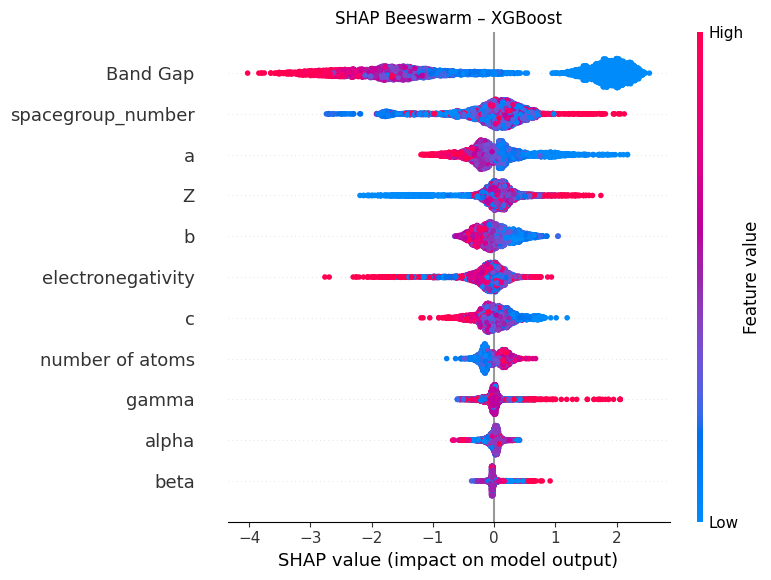

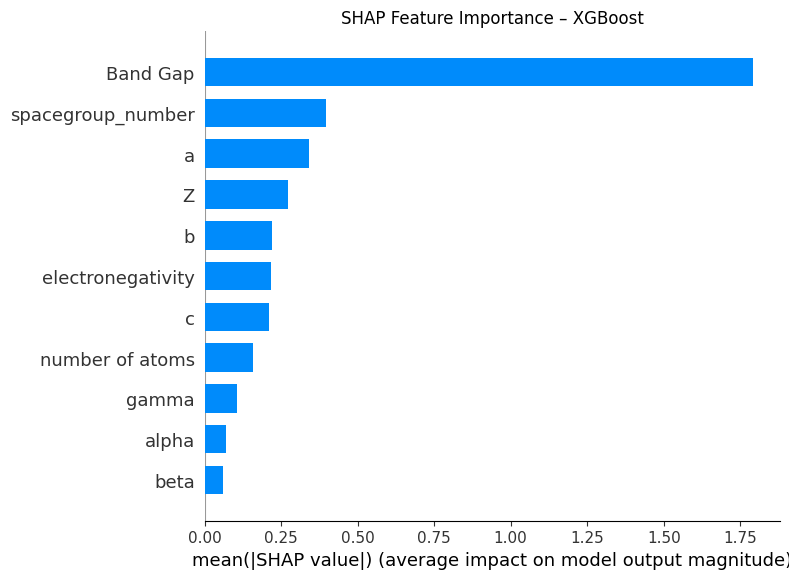

In [36]:
# Prepare global features and labels
X_train = train_df[global_cols].values
y_train = train_df['label'].values

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

# Summary plots
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_train, feature_names=global_cols, show=False)
plt.title('SHAP Beeswarm – XGBoost')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_train, feature_names=global_cols, plot_type='bar', show=False)
plt.title('SHAP Feature Importance – XGBoost')
plt.tight_layout()
plt.show()

In [37]:
# Use the same global features as above, target is the label
pysr = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=15,
    random_state=42
)
pysr.fit(X_train, y_train, variable_names=global_cols)

print("\n=== Best formulas ===")
print(pysr)
print("\nSympy representation of best formula:")
print(pysr.sympy())

ValueError: Variable name beta is already a function name.

In [ ]:
def plot_true_vs_pred(labels, probs, model_name):
    plt.figure(figsize=(5,5))
    plt.scatter(labels, probs, alpha=0.5)
    plt.xlabel('True Label')
    plt.ylabel('Predicted Probability (Class 1)')
    plt.title(f'{model_name} – Prediction Confidence')
    plt.plot([0,1], [0,1], 'r--')
    plt.show()

# For each model, get test probs (already computed in evaluation)
# Use the results from evaluate_model or recompute quickly
def get_probs(model, loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            probs.extend(F.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    return labels, probs

labels_cgcnn, probs_cgcnn = get_probs(model_cgcnn, test_loader)
labels_attn, probs_attn = get_probs(model_attn, test_loader)
labels_megnet, probs_megnet = get_probs(model_megnet, test_loader)

plot_true_vs_pred(labels_cgcnn, probs_cgcnn, "CGCNN")
plot_true_vs_pred(labels_attn, probs_attn, "Attention CGCNN")
plot_true_vs_pred(labels_megnet, probs_megnet, "MEGNet")

In [ ]:
torch.save(model_cgcnn.state_dict(), os.path.join(PROJECT_PATH, "CharlesCGCNN_final.pth"))
torch.save(model_attn.state_dict(), os.path.join(PROJECT_PATH, "CharlesAttentionCGCNN_final.pth"))
torch.save(model_megnet.state_dict(), os.path.join(PROJECT_PATH, "CharlesMEGNet_final.pth"))